# HPO for XOR using ES(1+1) with 1/5 rule optimizer

## 5 Hyperparameters
- hp0: Number of hidden layer neurons
- hp1: Learning rate
- hp2: Batch size
- hp3: Hidden layer activation function
- hp4: Optimization function

Important changes since F25
- loss function is not a HP
- Last layer activation function is fixed as sigmoid
- (1-acc) is used to calc error instead of loss

CJ Chung, cchung@LTU.edu

In [1]:
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Dropout, Activation, Input # Added Input
from tensorflow.keras import optimizers
import matplotlib.pyplot as plt
import numpy as np

act_func = ('elu', 'tanh', 'sigmoid') # put highly selectable fn in the center
# put highly selectble in the center
loss_func = ('mae', 'mse', 'binary_crossentropy', 'msle', 'hinge') # MLSE: Mean Squared Logarithmic Error
optimz = ('SGD', 'RMSprop', 'Adam')

X  = np.array([[0,0], [0,1], [1,0], [1,1]])
y  = np.array([[0],   [1],   [1],   [0]])

Xv = np.array([[0.1, 0.1], [0.15, 0.1], [0.1, 0.9], [0.15, 0.85], [0.9, 0.1], [0.9, 0.9], [0.85, 0.9]])
yv = np.array([[0],        [0],         [1],        [1],          [1],        [0],        [0] ])

# FINAL TEST (New data, unseen by the optimizer)

Xt = np.array([[0.1,0], [0.2,0.19], [0,0.9], [0.8, 0.1], [0.9,0.2], [0.9,0.9]])
yt = np.array([[0],     [0],        [1],     [1],        [1],       [0]])
# 0: num_neurons, 1: lr, 2: bsize, 3: actfun, 4: optmzr

def XOR_eval(hp):
  global model
  model = Sequential([
      Input(shape=(2,)), # Explicitly define input shape
      Dense(round(hp[0])), # Num hidden neurons
      Activation(act_func[ round(hp[3]) ]),
      Dense(1),
      Activation('sigmoid') # need to be sigmod. elu, tanh output values are not [0,1)
  ])
  if ( round(hp[4]) == 0 ):
    optmzr = optimizers.SGD(learning_rate=hp[1]) # stochastic gradient decent
  elif ( round(hp[4]) == 1 ):
    optmzr = optimizers.RMSprop(learning_rate=hp[1])
  elif ( round(hp[4]) == 2 ):
    optmzr = optimizers.Adam(learning_rate=hp[1])

  model.compile(loss='mse', optimizer=optmzr, metrics=['binary_accuracy'])
  # binary_accuracy: Calculates how often predictions match binary labels
  model.fit(X, y, batch_size=round(hp[2]), epochs=350, verbose=0)
  (loss, acc) = model.evaluate(Xv, yv, verbose=0)
  # FITNESS: Minimize Error (1.0 - Accuracy) DO NOT USE loss. Use acc instead
  # the 3 loss funcs produce numbers on completely different scales.
  # output layer actFuncs also has different values
  return (1.0 - acc) # <==== Important Change!

# Constants
MaxGen = 40
MaxTrial = 4
numVar = 5
# num_neurons, lr, actfun, bsize, optmzr
def print_HP_found(x, eval):
  print(f"#neurons={int(x[0])}, lr={x[1]:.3f}, bsize={int(x[2])}, actF={act_func[int(x[3])]}, optim={optimz[int(x[4])]})")
  print(f"Eval={eval:.5f}")

totgen = 0
foundCnt = 0  # acceptable solution found
objfunc = XOR_eval #
#np.random.seed(1) # makes the random numbers predictable to debug

# for 1/5 rule
stepSize_i = 0.82 # initial stepsize
stepSize_r = 0.82 # stepsize change ratio.
                  # 0.82 was used previously by Hans-Paul Schwefel, a PhD student of Rechenberg
print(f"[#neurons, lr, bsize, actfun, optmzr]")

# List to store paths of models that achieve 100% test accuracy
perfect_model_paths = []

for trial in range(0, MaxTrial):
    best_p_val = 9999 # a large number
    xp = np.empty(numVar) # parent
    p_val = 0
    xo = np.empty(numVar) # offspring
    o_val = 0

    successCnt = 0;
    WindowSize = 10

    print(f"************************** Trial # = {trial+1}")
    hparams = [
        (2, 2, 12),   # num hidden neuron, low_b, high_b
        (np.random.uniform(0.01, 1.5), 0.01, 1.5), # lr - removed round
        (2, 1, 4),   # batch size
        (1, 0, 2),   # act fn: ('elu', 'tanh', 'sigmoid')
        (1, 0, 2)    # optimizers: ('SGD', 'RMSprop', 'Adam')
    ]

    # Assign initial values to parent
    for i in range(numVar):
        xp[i] = hparams[i][0]

    p_val = objfunc(xp)     # evaluate the parent

    stepSize = stepSize_i

    for g in range(1, MaxGen+1):
        if (g % WindowSize) == 0:
            if successCnt > (WindowSize * 0.2):
                stepSize = stepSize / stepSize_r #increase
            elif successCnt < (WindowSize * 0.2):
                stepSize = stepSize * stepSize_r #decrease
            successCnt = 0

        # mutate each hyperparameter
        for i in range(numVar):
            if i == 1: # Learning rate, allow float mutation
                xo[i] = xp[i] + np.random.normal(0.0, stepSize)
            else: # Other parameters, round to integer
                xo[i] = xp[i] + round(np.random.normal(0.0, stepSize))
            # to correct if any variation goes out of acceptable range
            xo[i] = np.clip(xo[i], hparams[i][1], hparams[i][2]) # hparams[i][1]: lower_bound

        o_val = objfunc(xo)  # evaluate offspring

        # select
        if o_val < p_val:
            xp = xo.copy()
            p_val = o_val
            successCnt += 1;

        if p_val < 0.005: # we assume minima is zero.
            print(f"Acceptable solution found after {g} generations:")
            print_HP_found(xp, p_val)

            # Evaluate the *current* model (which achieved p_val < 0.005) on the unseen test data
            loss_test, acc_test = model.evaluate(Xt, yt, verbose=0)
            print(f"Final Accuracy on Unseen Data (for this model): {acc_test*100:.2f}%")
            print(f"Predictions (for this model):\n{model.predict(Xt, verbose=0).round(2)}")

            if acc_test == 1.0:
                print("SUCCESS: Model generalized perfectly for this trial!")
                perfect_model_filename = f"model_trial_{trial+1}_gen_{g}_perfect.keras"
                save_model(model, perfect_model_filename)
                perfect_model_paths.append(perfect_model_filename)
            else:
                print("WARNING: Model optimized well, but failed to generalize for current trial.")

            if p_val < best_p_val: # This is for the overall best model across trials based on validation accuracy
                best_p_val = p_val
                save_model(model, 'bestXOR.keras') # save current model as overall best based on p_val
            totgen += g
            foundCnt += 1
            break # cannot use while since it may not find acceptable minia
    # end of inner generation loop

    # After the inner loop, if no acceptable solution was found, or if an acceptable solution was found but didn't generalize perfectly.
    # The previous `loaded_model` logic here was problematic as it loaded the overall best based on validation, not the current trial's best.
    # The evaluation for 100% test accuracy is now inside the `if p_val < 0.005` block.
    # We don't need the `loaded_model` part here anymore, as the relevant evaluation for 100% test accuracy is already handled.

# end of Trial
print(f"*******System Success = {foundCnt/MaxTrial*100}%")
totgen += (MaxTrial-foundCnt)*MaxGen # This line should only account for trials where no acceptable solution was found
print(f"*******Avgerage # of generations used = {(totgen/MaxTrial):,.0f}")
print(f"Models that achieved 100% test accuracy and were saved: {perfect_model_paths}")

[#neurons, lr, bsize, actfun, optmzr]
************************** Trial # = 1
Acceptable solution found after 2 generations:
#neurons=4, lr=0.010, bsize=1, actF=elu, optim=Adam)
Eval=0.00000
Final Accuracy on Unseen Data (for this model): 100.00%
Predictions (for this model):
[[0.05]
 [0.07]
 [0.93]
 [0.77]
 [0.75]
 [0.06]]
SUCCESS: Model generalized perfectly for this trial!
************************** Trial # = 2
Acceptable solution found after 7 generations:
#neurons=2, lr=0.010, bsize=2, actF=tanh, optim=RMSprop)
Eval=0.00000
Final Accuracy on Unseen Data (for this model): 100.00%
Predictions (for this model):
[[0.14]
 [0.1 ]
 [0.85]
 [0.73]
 [0.71]
 [0.07]]
SUCCESS: Model generalized perfectly for this trial!
************************** Trial # = 3
Acceptable solution found after 1 generations:
#neurons=2, lr=1.500, bsize=2, actF=sigmoid, optim=SGD)
Eval=0.00000
Final Accuracy on Unseen Data (for this model): 83.33%
Predictions (for this model):
[[0.12]
 [0.57]
 [0.91]
 [0.91]
 [0.89

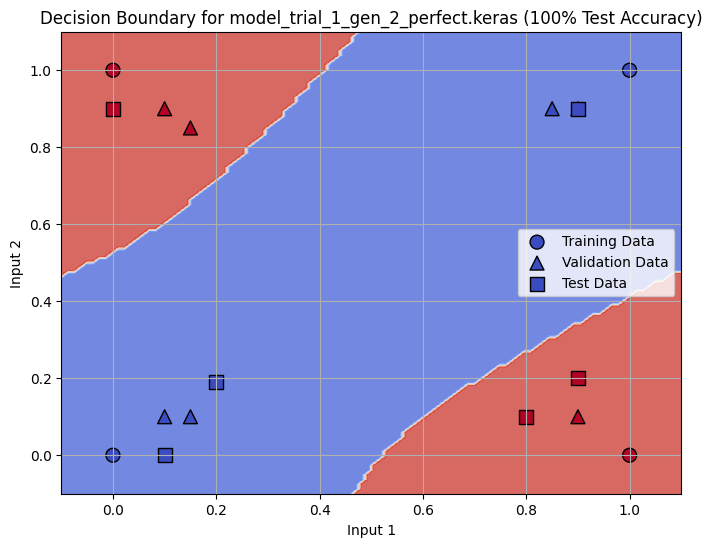

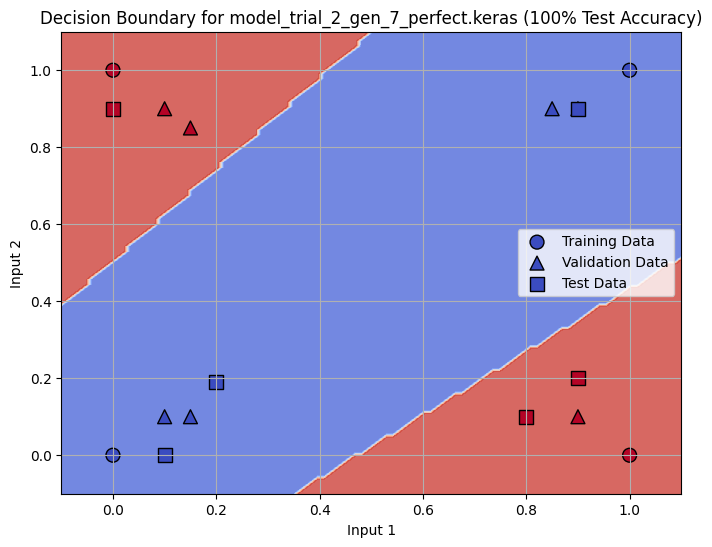

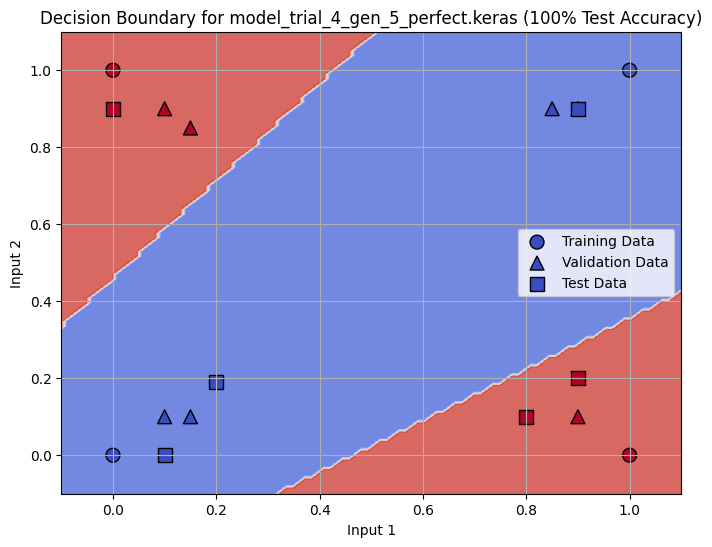

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model

# Define the input range for plotting the decision boundary
x_min, x_max = -0.1, 1.1
y_min, y_max = -0.1, 1.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Iterate through each perfect model and plot its decision boundary
for model_path in perfect_model_paths:
    # Load the specific model that achieved 100% test accuracy
    perfect_model = load_model(model_path)

    # Predict on the meshgrid points
    Z = perfect_model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = (Z > 0.5).astype(int) # Convert output to binary 0 or 1 with a 0.5 threshold
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

    # Plot the training points
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap=plt.cm.coolwarm, edgecolors='k', marker='o', s=100, label='Training Data')

    # Plot the validation points
    plt.scatter(Xv[:, 0], Xv[:, 1], c=yv.flatten(), cmap=plt.cm.coolwarm, edgecolors='k', marker='^', s=100, label='Validation Data')

    # Plot the test points
    plt.scatter(Xt[:, 0], Xt[:, 1], c=yt.flatten(), cmap=plt.cm.coolwarm, edgecolors='k', marker='s', s=100, label='Test Data')

    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.title(f'Decision Boundary for {model_path} (100% Test Accuracy)')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.legend()
    plt.grid(True)
    plt.show()